# 1. Import Libraries & Load Dataset

In [3]:
import pandas as pd
import numpy as np
import pickle
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import Dataset
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer

BASE_DIR = Path.cwd().parents[1]
DATA_DIR = BASE_DIR / 'data'
MODEL_DIR = BASE_DIR / 'models' / 'distilbert_prod'

TEST_PATH = DATA_DIR / '(prod)data_test_master.csv'
test_df = pd.read_csv(TEST_PATH)

# 2. Evaluation

In [4]:
X_test_text = test_df['clean_text'].astype(str).tolist()
y_test_text = test_df['emotion_label'].tolist()

## Tokenization & Class Dataset

In [5]:
with open(MODEL_DIR / 'label_encoder.pkl', 'rb') as handle:
    label_encoder = pickle.load(handle)
    
y_test_encoded = label_encoder.transform(y_test_text)

tokenizer = DistilBertTokenizer.from_pretrained(MODEL_DIR)
model = DistilBertForSequenceClassification.from_pretrained(MODEL_DIR)

test_encodings = tokenizer(X_test_text, truncation=True, padding=True, max_length=60)

class EmotionTestDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

test_dataset = EmotionTestDataset(test_encodings, y_test_encoded)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2878.63it/s]


## Predicting

In [6]:
trainer = Trainer(model=model)
preds = trainer.predict(test_dataset)

y_pred_encoded = np.argmax(preds.predictions, axis=1)
y_pred_text = label_encoder.inverse_transform(y_pred_encoded)

c:\Users\VICTUS\OneDrive\Documents\Edwin's_Project\Moofy\emovie\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## Evaluate & Plot


=== Classification Report: DistilBERT (Production Data) ===
              precision    recall  f1-score   support

       Anger       0.75      0.78      0.77      1567
        Fear       0.67      0.67      0.67       639
         Joy       0.74      0.71      0.73      1552
        Love       0.81      0.84      0.83      1500
     Sadness       0.71      0.71      0.71      1305
    Surprise       0.73      0.71      0.72      1089

    accuracy                           0.74      7652
   macro avg       0.74      0.74      0.74      7652
weighted avg       0.74      0.74      0.74      7652



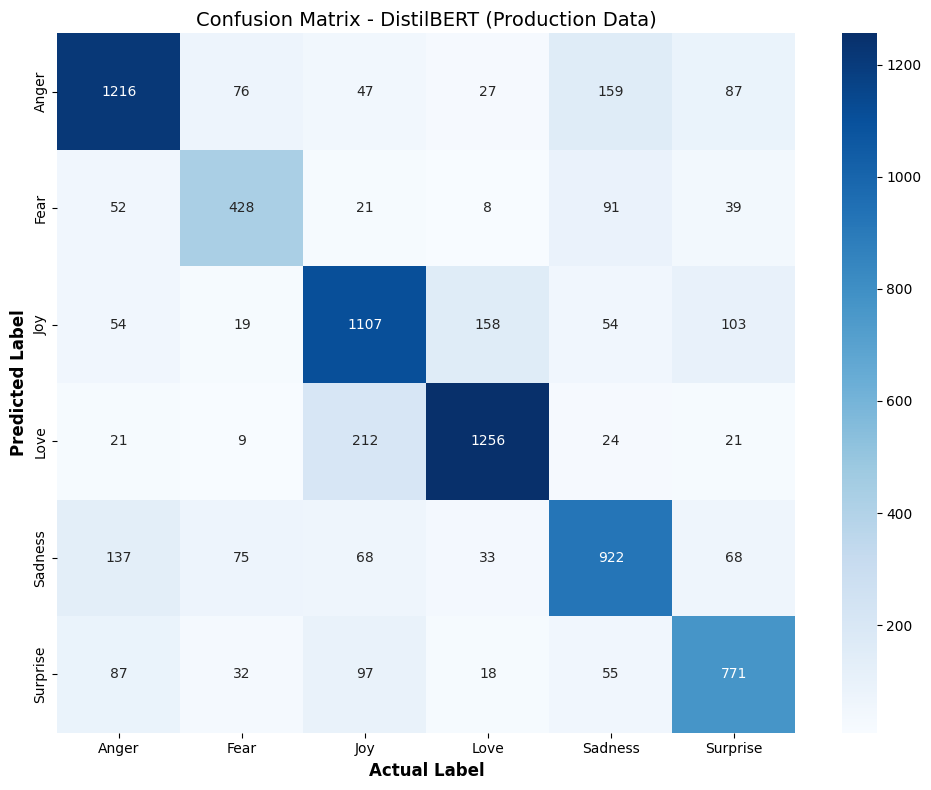

In [7]:
def evaluate_and_plot(y_true, y_pred, classes, title):
    print(f"\n=== Classification Report: {title} ===")
    print(classification_report(y_true, y_pred, target_names=classes))
    
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    cm_transposed = cm.T 
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_transposed, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    
    plt.title(f'Confusion Matrix - {title}', fontsize=14)
    plt.ylabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.xlabel('Actual Label', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

evaluate_and_plot(y_test_text, y_pred_text, label_encoder.classes_, "DistilBERT (Production Data)")

The decrease in accuracy from 0.77 to 0.74 is an expected trade-off resulting from the improved data-labeling strategy.

- **Rarer Emotion Priority:** Multi-label instances are now assigned to their rarest emotion, encouraging the model to learn minority classes such as Fear and Surprise rather than favoring majority classes.

- **More Reliable Evaluation:** The previous 0.77 accuracy was influenced by class imbalance. The current 0.74 accuracy provides a more representative measure of performance on the refined dataset.

- **Stable F1-Scores:** Strong class-level F1-scores, such as Love (0.83) and Anger (0.77), indicate that the model's core predictive capability remains intact.

- **Conclusion:** Although accuracy decreased slightly, the new model provides a more balanced and reliable emotion classification, making it better suited for downstream movie recommendation based on TMDB synopses.